In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer

In [2]:
data = pd.read_csv("Housing.csv")

data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
num_cols = data.select_dtypes(include='number')

num_cols.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='str')

In [4]:
skewness = num_cols.skew().sort_values(ascending=False)

print(skewness)

bathrooms    1.589264
area         1.321188
price        1.212239
stories      1.082088
parking      0.842062
bedrooms     0.495684
dtype: float64


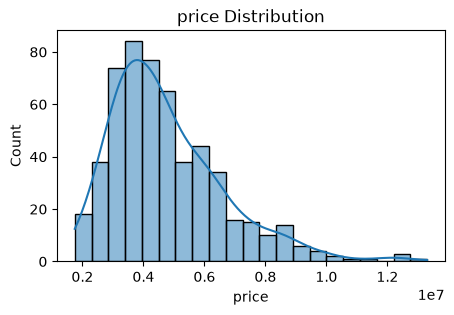

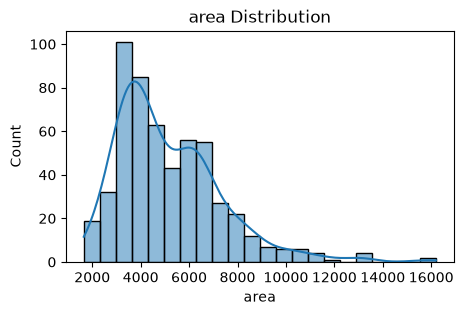

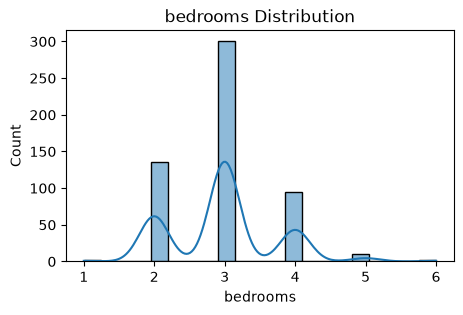

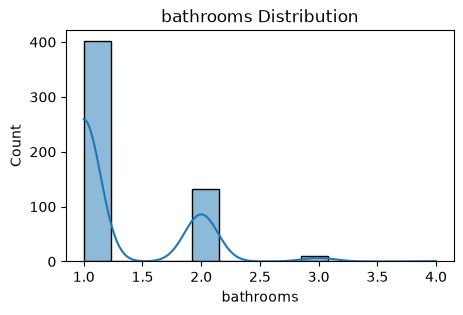

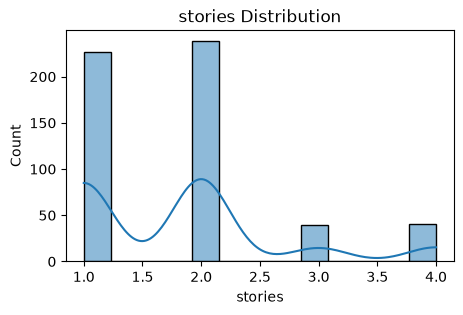

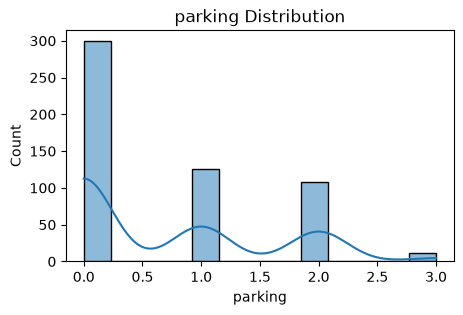

In [5]:
for col in num_cols.columns:
    plt.figure(figsize=(5,3))
    sns.histplot(data[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

In [6]:
log_data = data.copy()

for col in ['price','area','bathrooms','stories','parking']:
    log_data[col] = np.log1p(log_data[col])

In [7]:
sqrt_data = data.copy()

for col in ['price','area','bathrooms','stories','parking']:
    sqrt_data[col] = np.sqrt(sqrt_data[col])

In [10]:
cube_data = data.copy()

for col in ['price','area','bathrooms','stories']:
    cube_data[col] = np.cbrt(cube_data[col])

In [11]:
yeo_data = data.copy()

pt = PowerTransformer(method='yeo-johnson')

yeo_data[['price','area','bathrooms','stories','parking']] = pt.fit_transform(
    yeo_data[['price','area','bathrooms','stories','parking']]
)

In [12]:
comparison = pd.DataFrame({
    "Original": data[num_cols.columns].skew(),
    "Log": log_data[num_cols.columns].skew(),
    "Square Root": sqrt_data[num_cols.columns].skew(),
    "Cube Root": cube_data[num_cols.columns].skew(),
    "Box-Cox": boxcox_data[num_cols.columns].skew(),
    "Yeo-Johnson": yeo_data[num_cols.columns].skew()
})

comparison.round(3)

,Original,Log,Square Root,Cube Root,Box-Cox,Yeo-Johnson
price,1.212,0.141,0.660,0.484,1.212,0.003
area,1.321,0.134,0.683,0.493,1.321,0.004
bedrooms,0.496,0.496,0.496,0.496,0.496,0.496
bathrooms,1.589,1.310,1.359,1.307,1.589,1.073
stories,1.082,0.526,0.654,0.526,1.082,0.121
parking,0.842,0.502,0.387,0.842,0.842,0.311


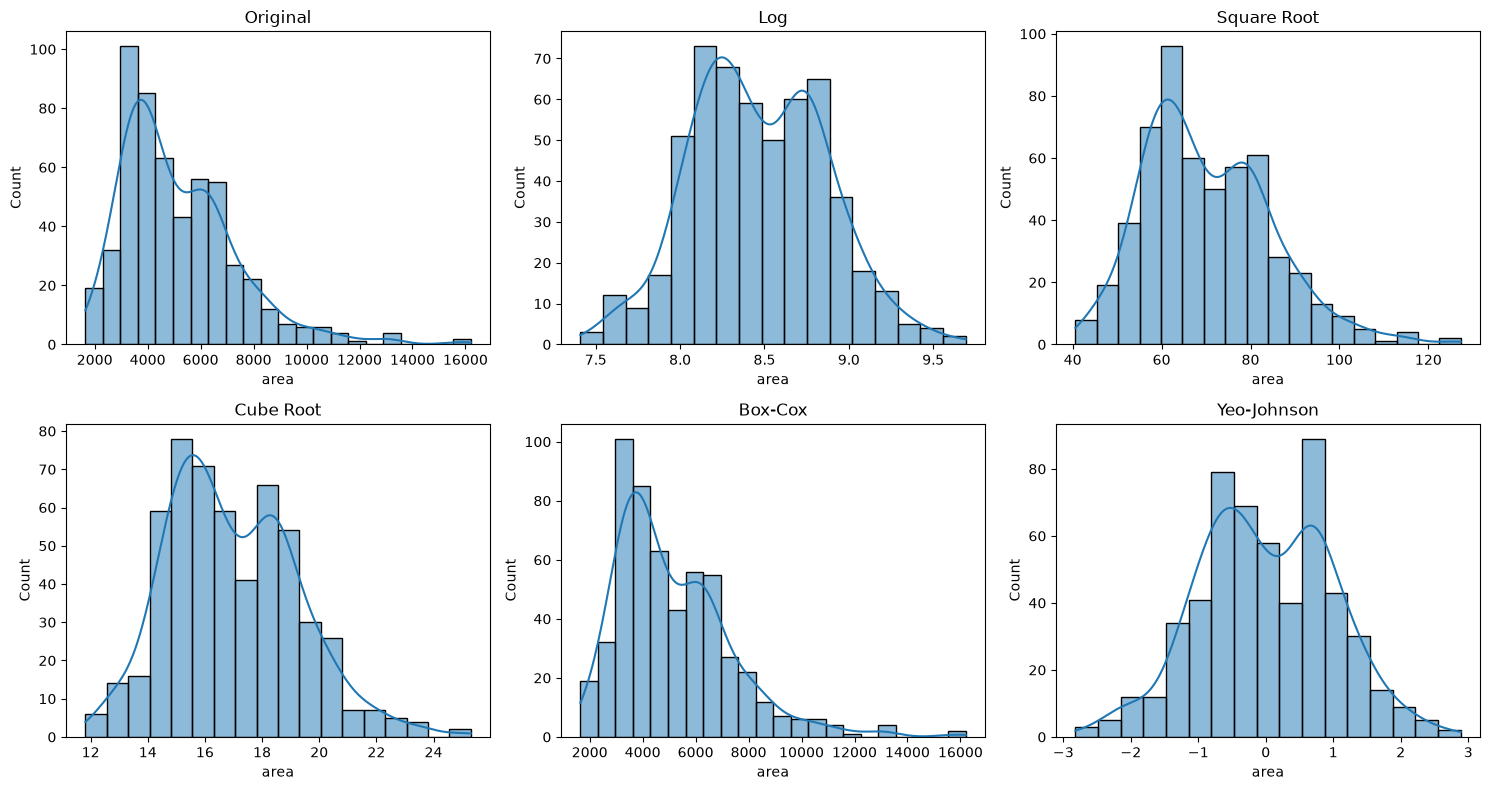

In [13]:
fig, axes = plt.subplots(2,3, figsize=(15,8))

datasets = [
    ("Original", data),
    ("Log", log_data),
    ("Square Root", sqrt_data),
    ("Cube Root", cube_data),
    ("Box-Cox", boxcox_data),
    ("Yeo-Johnson", yeo_data)
]

for ax, (name, dataset) in zip(axes.flatten(), datasets):
    sns.histplot(dataset["area"], kde=True, ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()